# Bird Audio Dataset Cleaning + EDA Notebook

This notebook is an end-to-end template for preparing `Dataset_5` for conditional bird-chirp generation.


## 0) Setup and Package Installation


In [1]:
%pip install -q --upgrade pip
%pip install -q pandas numpy scipy matplotlib seaborn plotly tqdm scikit-learn pyarrow xxhash librosa soundfile


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import xxhash

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RNG = np.random.default_rng(42)
print("Imports OK")


C:\Users\Legion\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 1) Paths and Runtime Configuration


In [4]:
# Update ROOT if needed
ROOT = Path.cwd()
DATASET_DIR = ROOT / "Dataset_5"
WAV_DIR = DATASET_DIR / "wavfiles"
META_PATH = DATASET_DIR / "bird_songs_metadata.csv"

ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

# Audio assumptions / target format
TARGET_SR = 22050
CLIP_LEN_SEC = 3.0
CLIP_LEN_ATOL = 0.02
RANDOM_SEED = 42

# QC controls
RUN_FULL_QC = True
QC_SAMPLE_N = 1500

# Near-duplicate controls
RUN_NEAR_DUP = False          # set True if you want to run this block
NEAR_DUP_MAX_FILES = 3000     # cap for runtime safety
NEAR_DUP_K = 6                # neighbors per file
NEAR_DUP_DISTANCE_MAX = 0.05  # cosine distance threshold (smaller = more similar)

print("ROOT:", ROOT)
print("DATASET_DIR exists:", DATASET_DIR.exists())
print("WAV_DIR exists:", WAV_DIR.exists())
print("META_PATH exists:", META_PATH.exists())


ROOT: c:\Users\Legion\Desktop\project
DATASET_DIR exists: True
WAV_DIR exists: True
META_PATH exists: True


## 2) Load and Validate Metadata


In [4]:
required_cols = [
    "id", "genus", "species", "country", "source_url", "license", "date", "filename"
]

meta = pd.read_csv(META_PATH, dtype={"id": "string"})
meta.columns = [c.strip() for c in meta.columns]

missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f"Metadata missing required columns: {missing_cols}")

meta["filename"] = meta["filename"].astype(str).str.strip()
meta["meta_recording_id"] = meta["id"].astype(str).str.strip()
meta["species_label"] = (
    meta["genus"].astype(str).str.strip() + " " + meta["species"].astype(str).str.strip()
)

print("Metadata shape:", meta.shape)
print("Unique species:", meta["species_label"].nunique())
print("Unique metadata recording ids:", meta["meta_recording_id"].nunique())
display(meta.head(3))


Metadata shape: (5422, 20)
Unique species: 5
Unique metadata recording ids: 477


,id,genus,species,subspecies,name,recordist,country,location,latitude,longitude,altitude,sound_type,source_url,license,time,date,remarks,filename,meta_recording_id,species_label
0,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-0.wav,557838,Thryomanes bewickii
1,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-1.wav,557838,Thryomanes bewickii
2,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-4.wav,557838,Thryomanes bewickii


In [5]:
meta_dupe_filename = meta["filename"].duplicated().sum()
meta_dupe_id = meta.duplicated(subset=["meta_recording_id", "filename"]).sum()

print("Duplicate filenames in metadata:", int(meta_dupe_filename))
print("Duplicate (recording_id, filename) rows:", int(meta_dupe_id))

display(meta["species_label"].value_counts().rename_axis("species").to_frame("metadata_count"))


Duplicate filenames in metadata: 0
Duplicate (recording_id, filename) rows: 0


,metadata_count
species,
Melospiza melodia,1256
Mimus polyglottos,1182
Cardinalis cardinalis,1074
Turdus migratorius,1017
Thryomanes bewickii,893


## 3) Enumerate Audio Files and Build Unified Manifest


In [6]:
wav_paths = sorted(WAV_DIR.glob("*.wav"))
wav_df = pd.DataFrame(
    {
        "filepath": [str(p) for p in wav_paths],
        "filename": [p.name for p in wav_paths],
    }
)

# Expected naming: <recording_id>-<segment>.wav
wav_df["recording_id"] = wav_df["filename"].str.split("-").str[0]

# Keep one metadata row per filename
meta_key = meta.drop_duplicates(subset=["filename"], keep="first").copy()

manifest = wav_df.merge(
    meta_key,
    on="filename",
    how="left",
    validate="one_to_one",
)
manifest["label_known"] = manifest["species_label"].notna().astype(int)

print("Total wav files:", len(manifest))
print("Labeled files:", int(manifest["label_known"].sum()))
print("Unlabeled files:", int((manifest["label_known"] == 0).sum()))
print("Labeled fraction:", round(float(manifest["label_known"].mean()), 4))

display(manifest.head(3))


Total wav files: 9107
Labeled files: 5422
Unlabeled files: 3685
Labeled fraction: 0.5954


,filepath,filename,recording_id,id,genus,species,subspecies,name,recordist,country,location,latitude,longitude,altitude,sound_type,source_url,license,time,date,remarks,meta_recording_id,species_label,label_known
0,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,101308-0.wav,101308,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,101308-1.wav,101308,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,101308-10.wav,101308,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [7]:
# Coverage diagnostics
meta_filename_set = set(meta["filename"].dropna().astype(str))
wav_filename_set = set(manifest["filename"].astype(str))

missing_on_disk = sorted(meta_filename_set - wav_filename_set)
extra_on_disk = sorted(wav_filename_set - meta_filename_set)

print("Metadata filenames not found in wav dir:", len(missing_on_disk))
print("Wav files without metadata rows:", len(extra_on_disk))

# ID consistency check for labeled rows
id_check = manifest[manifest["label_known"] == 1].copy()
id_check["id_match"] = id_check["recording_id"].astype(str) == id_check["meta_recording_id"].astype(str)
print("Recording ID mismatches on labeled rows:", int((~id_check["id_match"]).sum()))


Metadata filenames not found in wav dir: 0
Wav files without metadata rows: 3685
Recording ID mismatches on labeled rows: 0


## 4) Audio Technical Checks (sr / duration / channels / encoding)


In [8]:
def safe_audio_info(path):
    try:
        info = sf.info(path)
        return {
            "sr": int(info.samplerate),
            "frames": int(info.frames),
            "duration_sec": float(info.duration),
            "channels": int(info.channels),
            "subtype": str(info.subtype),
            "format": str(info.format),
            "read_error": 0,
        }
    except Exception:
        return {
            "sr": np.nan,
            "frames": np.nan,
            "duration_sec": np.nan,
            "channels": np.nan,
            "subtype": np.nan,
            "format": np.nan,
            "read_error": 1,
        }

audio_info = [safe_audio_info(p) for p in tqdm(manifest["filepath"], desc="Reading audio headers")]
audio_info = pd.DataFrame(audio_info)
manifest = pd.concat([manifest.reset_index(drop=True), audio_info], axis=1)

manifest["is_target_sr"] = manifest["sr"].eq(TARGET_SR)
manifest["is_target_len"] = np.isclose(manifest["duration_sec"], CLIP_LEN_SEC, atol=CLIP_LEN_ATOL)
manifest["is_mono"] = manifest["channels"].eq(1)

display(manifest[["sr", "duration_sec", "channels", "subtype", "format", "read_error"]].describe(include="all"))
print("Read errors:", int(manifest["read_error"].sum()))
print("Non-target sr rows:", int((~manifest["is_target_sr"]).sum()))
print("Non-target duration rows:", int((~manifest["is_target_len"]).sum()))
print("Non-mono rows:", int((~manifest["is_mono"]).sum()))


Reading audio headers: 100%|██████████| 9107/9107 [00:01<00:00, 6339.99it/s]


,sr,duration_sec,channels,subtype,format,read_error
count,9107.0,9107.0,9107.0,9107,9107,9107.0
unique,NaN,NaN,NaN,1,1,NaN
top,NaN,NaN,NaN,FLOAT,WAV,NaN
freq,NaN,NaN,NaN,9107,9107,NaN
mean,22050.0,3.0,1.0,NaN,NaN,0.0
std,0.0,0.0,0.0,NaN,NaN,0.0
min,22050.0,3.0,1.0,NaN,NaN,0.0
25%,22050.0,3.0,1.0,NaN,NaN,0.0
50%,22050.0,3.0,1.0,NaN,NaN,0.0
75%,22050.0,3.0,1.0,NaN,NaN,0.0


Read errors: 0
Non-target sr rows: 0
Non-target duration rows: 0
Non-mono rows: 0


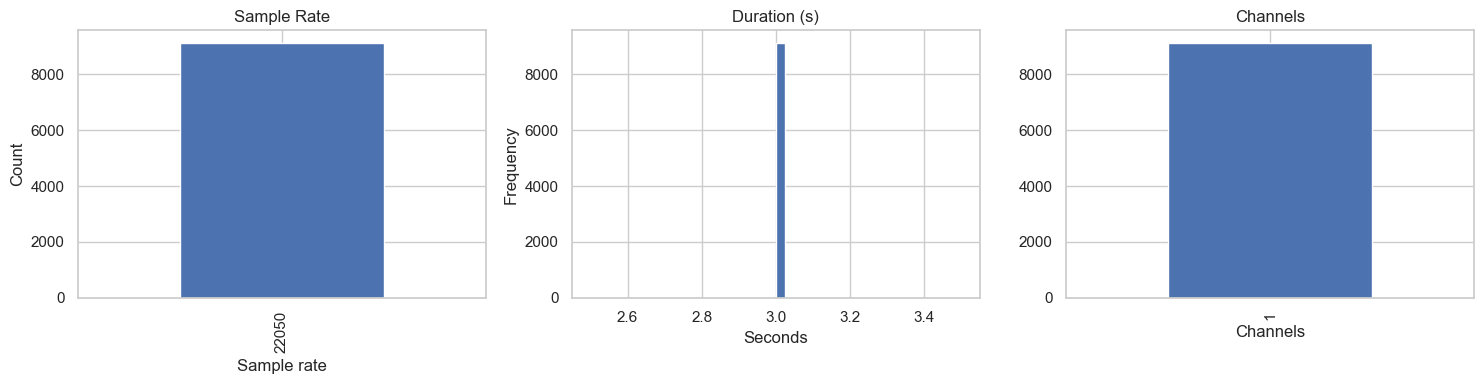

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
manifest["sr"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Sample Rate")
axes[0].set_xlabel("Sample rate")
axes[0].set_ylabel("Count")

manifest["duration_sec"].dropna().plot(kind="hist", bins=40, ax=axes[1], title="Duration (s)")
axes[1].set_xlabel("Seconds")

manifest["channels"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Channels")
axes[2].set_xlabel("Channels")

plt.tight_layout()


## 5) Label and Metadata EDA


,count
species,
Melospiza melodia,1256
Mimus polyglottos,1182
Cardinalis cardinalis,1074
Turdus migratorius,1017
Thryomanes bewickii,893


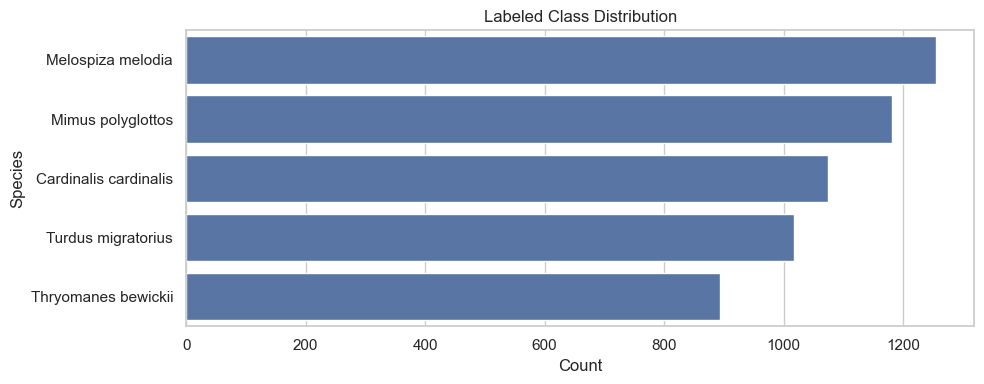

In [10]:
labeled = manifest[manifest["label_known"] == 1].copy()

display(labeled["species_label"].value_counts().rename_axis("species").to_frame("count"))

plt.figure(figsize=(10, 4))
sns.countplot(data=labeled, y="species_label", order=labeled["species_label"].value_counts().index)
plt.title("Labeled Class Distribution")
plt.xlabel("Count")
plt.ylabel("Species")
plt.tight_layout()


In [11]:
if "date" in labeled.columns:
    labeled["date_parsed"] = pd.to_datetime(labeled["date"], errors="coerce")
    print("Date range:", labeled["date_parsed"].min(), "to", labeled["date_parsed"].max())

if "country" in labeled.columns:
    display(labeled["country"].value_counts().head(10).rename_axis("country").to_frame("count"))

if "license" in labeled.columns:
    display(labeled["license"].value_counts().head(10).rename_axis("license").to_frame("count"))


Date range: 1995-04-09 00:00:00 to 2020-06-04 00:00:00


,count
country,
United States,5422


,count
license,
//creativecommons.org/licenses/by-nc-sa/4.0/,3596
//creativecommons.org/licenses/by-nc-nd/2.5/,811
//creativecommons.org/licenses/by-nc-sa/3.0/,545
//creativecommons.org/licenses/by-nc-nd/4.0/,343
//creativecommons.org/licenses/by-sa/3.0/,105
//creativecommons.org/licenses/by-sa/4.0/,22


## 6) Signal Quality Checks

Tune thresholds after listening to flagged examples.

In [12]:
def quality_metrics(path, target_sr=TARGET_SR):
    out = {
        "rms": np.nan,
        "peak_abs": np.nan,
        "zcr": np.nan,
        "clip_ratio": np.nan,
        "dc_offset": np.nan,
        "qc_error": 0,
    }
    try:
        y, _ = librosa.load(path, sr=target_sr, mono=True)
        if y.size == 0:
            out["qc_error"] = 1
            return out

        y = y.astype(np.float32)
        out["peak_abs"] = float(np.max(np.abs(y)))
        out["rms"] = float(np.sqrt(np.mean(y ** 2)))
        out["zcr"] = float(librosa.feature.zero_crossing_rate(y, frame_length=2048, hop_length=512).mean())
        out["clip_ratio"] = float(np.mean(np.abs(y) >= 0.999))
        out["dc_offset"] = float(np.mean(y))
    except Exception:
        out["qc_error"] = 1
    return out

if RUN_FULL_QC:
    qc_df_input = manifest.copy()
else:
    n = min(QC_SAMPLE_N, len(manifest))
    qc_df_input = manifest.sample(n=n, random_state=RANDOM_SEED).copy()

qc_metrics = [quality_metrics(p) for p in tqdm(qc_df_input["filepath"], desc="Computing QC metrics")]
qc_df = pd.concat([qc_df_input.reset_index(drop=True), pd.DataFrame(qc_metrics)], axis=1)

# Thresholds (starting defaults)
RMS_MIN = float(max(1e-5, qc_df["rms"].quantile(0.01)))
CLIP_RATIO_MAX = 0.01
DC_OFFSET_MAX = 0.05

qc_df["flag_low_energy"] = qc_df["rms"] < RMS_MIN
qc_df["flag_clipping"] = qc_df["clip_ratio"] > CLIP_RATIO_MAX
qc_df["flag_dc_offset"] = np.abs(qc_df["dc_offset"]) > DC_OFFSET_MAX
qc_df["flag_bad"] = (
    qc_df[["flag_low_energy", "flag_clipping", "flag_dc_offset"]].any(axis=1)
    | (qc_df["qc_error"] == 1)
)

display(qc_df[["rms", "peak_abs", "zcr", "clip_ratio", "dc_offset", "qc_error"]].describe())
print("RUN_FULL_QC:", RUN_FULL_QC)
print("QC rows evaluated:", len(qc_df))
print("RMS_MIN:", round(RMS_MIN, 6), "CLIP_RATIO_MAX:", CLIP_RATIO_MAX, "DC_OFFSET_MAX:", DC_OFFSET_MAX)
display(qc_df[["flag_low_energy", "flag_clipping", "flag_dc_offset", "flag_bad"]].mean().to_frame("fraction"))


Computing QC metrics: 100%|██████████| 9107/9107 [00:14<00:00, 608.09it/s]


,rms,peak_abs,zcr,clip_ratio,dc_offset,qc_error
count,9107.000000,9107.0,9107.000000,9107.000000,9107.000000,9107.0
mean,0.133347,1.0,0.262858,0.000019,-0.000615,0.0
std,0.046023,0.0,0.104105,0.000173,0.005224,0.0
min,0.012059,1.0,0.001957,0.000015,-0.085343,0.0
25%,0.102384,1.0,0.200233,0.000015,-0.000019,0.0
50%,0.128713,1.0,0.265974,0.000015,-0.000003,0.0
75%,0.158329,1.0,0.339404,0.000015,0.000005,0.0
max,0.442868,1.0,0.679241,0.009554,0.118397,0.0


RUN_FULL_QC: True
QC rows evaluated: 9107
RMS_MIN: 0.045467 CLIP_RATIO_MAX: 0.01 DC_OFFSET_MAX: 0.05


,fraction
flag_low_energy,0.010102
flag_clipping,0.000000
flag_dc_offset,0.003075
flag_bad,0.013177


In [13]:
# Quick inspection of worst-quality candidates (by low RMS and high clipping)
show_n = 10

print("Lowest-RMS files:")
display(
    qc_df.sort_values("rms", ascending=True)[["filename", "rms", "clip_ratio", "dc_offset"]].head(show_n)
)

print("Highest clipping-ratio files:")
display(
    qc_df.sort_values("clip_ratio", ascending=False)[["filename", "rms", "clip_ratio", "dc_offset"]].head(show_n)
)


Lowest-RMS files:


,filename,rms,clip_ratio,dc_offset
3851,317266-13.wav,0.012059,0.000015,-2.252175e-05
3854,317266-3.wav,0.014089,0.000015,-3.540709e-06
3850,317266-12.wav,0.014629,0.000015,-3.062214e-06
6642,440010-5.wav,0.018044,0.000015,-4.270575e-07
3853,317266-2.wav,0.019483,0.000015,-3.006318e-06
5639,376038-1.wav,0.020300,0.000015,-8.725447e-07
4775,351038-11.wav,0.020538,0.000015,-7.130226e-06
4559,326450-8.wav,0.021400,0.000015,-1.865839e-04
773,126708-12.wav,0.022567,0.000015,-3.147860e-06
7778,513350-9.wav,0.022582,0.000015,2.384551e-05


Highest clipping-ratio files:


,filename,rms,clip_ratio,dc_offset
2632,205433-2.wav,0.254056,0.009554,-0.000568
2628,205433-1.wav,0.295579,0.009554,-0.006248
2633,205433-3.wav,0.232150,0.009554,-0.002467
5593,375274-6.wav,0.257085,0.000438,0.031254
8395,56154-3.wav,0.352480,0.000423,0.000040
2627,205433-0.wav,0.270419,0.000212,0.002442
2629,205433-10.wav,0.165461,0.000060,0.000167
2630,205433-11.wav,0.163777,0.000060,-0.000113
5498,370940-7.wav,0.238763,0.000060,-0.004827
2654,205751-0.wav,0.210664,0.000060,-0.000027


## 7) Exact Duplicate Detection


In [14]:
def file_hash(path, block_size=1 << 20):
    h = xxhash.xxh3_64()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

hash_df = manifest[["filepath", "filename", "recording_id", "species_label", "label_known"]].copy()
hash_df["file_hash"] = [file_hash(p) for p in tqdm(hash_df["filepath"], desc="Hashing files")]

hash_df["dup_rank"] = hash_df.groupby("file_hash").cumcount()
dup_groups = hash_df.groupby("file_hash").size()

print("Duplicate hash groups:", int((dup_groups > 1).sum()))
print("Files in duplicate groups:", int(dup_groups[dup_groups > 1].sum()))


Hashing files: 100%|██████████| 9107/9107 [00:01<00:00, 7668.06it/s]

Duplicate hash groups: 16
Files in duplicate groups: 40


## 8) Near-Duplicate Detection (MFCC Embedding, Optional)

Set `RUN_NEAR_DUP=True` to execute.

In [15]:
def load_audio_fixed(path, target_sr=TARGET_SR, clip_len_sec=CLIP_LEN_SEC):
    y, sr = sf.read(path, dtype="float32", always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    target_n = int(target_sr * clip_len_sec)
    if len(y) < target_n:
        y = np.pad(y, (0, target_n - len(y)))
    else:
        y = y[:target_n]
    return y.astype(np.float32)


def mfcc_embedding(path, n_mfcc=20):
    y = load_audio_fixed(path)
    mfcc = librosa.feature.mfcc(y=y, sr=TARGET_SR, n_mfcc=n_mfcc, n_fft=1024, hop_length=256)
    d1 = librosa.feature.delta(mfcc)
    emb = np.concatenate([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        d1.mean(axis=1), d1.std(axis=1),
    ]).astype(np.float32)
    emb = np.nan_to_num(emb)
    norm = np.linalg.norm(emb) + 1e-8
    return emb / norm

near_pairs = pd.DataFrame(columns=[
    "filename_a", "filename_b", "distance", "same_recording_id", "same_species", "near_dup"
])
near_dup_drop_set = set()

if RUN_NEAR_DUP:
    near_input = manifest[(manifest["label_known"] == 1) & (manifest["read_error"] == 0)].copy()
    if len(near_input) > NEAR_DUP_MAX_FILES:
        near_input = near_input.sample(NEAR_DUP_MAX_FILES, random_state=RANDOM_SEED)

    if len(near_input) >= 2:
        embs = [mfcc_embedding(p) for p in tqdm(near_input["filepath"], desc="Embedding for near-dup")]
        X = np.vstack(embs)

        k = int(min(NEAR_DUP_K, len(near_input)))
        nn = NearestNeighbors(n_neighbors=k, metric="cosine")
        nn.fit(X)
        distances, indices = nn.kneighbors(X)

        rows = []
        near_input = near_input.reset_index(drop=True)
        for i in range(len(near_input)):
            for n in range(1, k):
                j = int(indices[i, n])
                if i >= j:
                    continue
                rows.append(
                    {
                        "filename_a": near_input.loc[i, "filename"],
                        "filename_b": near_input.loc[j, "filename"],
                        "distance": float(distances[i, n]),
                        "same_recording_id": str(near_input.loc[i, "recording_id"]) == str(near_input.loc[j, "recording_id"]),
                        "same_species": str(near_input.loc[i, "species_label"]) == str(near_input.loc[j, "species_label"]),
                    }
                )

        near_pairs = pd.DataFrame(rows)
        if len(near_pairs) > 0:
            near_pairs["near_dup"] = (
                (near_pairs["distance"] <= NEAR_DUP_DISTANCE_MAX)
                & near_pairs["same_species"]
            )
            near_pairs = near_pairs.sort_values("distance", ascending=True).reset_index(drop=True)

            flagged = near_pairs[near_pairs["near_dup"]]
            # Keep first file, mark the partner for potential removal
            near_dup_drop_set = set(flagged["filename_b"].tolist())

        print("Near-pair rows:", len(near_pairs))
        print("Flagged near-duplicate pairs:", int(near_pairs["near_dup"].sum()) if len(near_pairs) else 0)
        print("Files marked to drop from near-dup pass:", len(near_dup_drop_set))
    else:
        print("Not enough files for near-duplicate analysis.")
else:
    print("Skipping near-duplicate detection (RUN_NEAR_DUP=False).")


Skipping near-duplicate detection (RUN_NEAR_DUP=False).


In [16]:
if len(near_pairs):
    display(near_pairs.head(20))


## 9) Cleaning Decisions and Final Training Table


In [18]:
clean = manifest.copy()

# Merge QC (may be partial if RUN_FULL_QC=False)
qc_flags = qc_df[[
    "filename", "flag_low_energy", "flag_clipping", "flag_dc_offset", "flag_bad", "qc_error"
]].copy()
clean = clean.merge(qc_flags, on="filename", how="left")

# Merge exact duplicate info
clean = clean.merge(hash_df[["filename", "file_hash", "dup_rank"]], on="filename", how="left")

# Near-dup mark
clean["flag_near_dup"] = clean["filename"].isin(near_dup_drop_set)

# If QC is partial, unevaluated rows should not be auto-dropped
for c in ["flag_low_energy", "flag_clipping", "flag_dc_offset", "flag_bad"]:
    clean[c] = clean[c].fillna(False)
clean["qc_error"] = clean["qc_error"].fillna(0).astype(int)

clean["keep_for_training"] = (
    (clean["label_known"] == 1)
    & (clean["read_error"] == 0)
    & clean["is_target_sr"]
    & clean["is_target_len"]
    & (~clean["flag_bad"])
    & (clean["dup_rank"].fillna(0) == 0)
    & (~clean["flag_near_dup"])
)

# Single-priority reason for non-kept rows
conditions = [
    clean["label_known"] != 1,
    clean["read_error"] != 0,
    ~clean["is_target_sr"],
    ~clean["is_target_len"],
    clean["flag_bad"],
    clean["dup_rank"].fillna(0) > 0,
    clean["flag_near_dup"],
]
choices = [
    "unlabeled",
    "read_error",
    "non_target_sr",
    "non_target_duration",
    "qc_flagged",
    "exact_duplicate",
    "near_duplicate",
]
clean["drop_reason"] = np.select(conditions, choices, default="")

train_table = clean[clean["keep_for_training"]].copy()

print("Rows in full manifest:", len(clean))
print("Rows kept for training:", len(train_table))
print("Keep rate:", round(len(train_table) / max(1, len(clean)), 4))

display(clean["drop_reason"].value_counts().rename_axis("reason").to_frame("count"))
display(train_table["species_label"].value_counts().rename_axis("species").to_frame("kept_count"))


Rows in full manifest: 9107
Rows kept for training: 5348
Keep rate: 0.5872


,count
reason,
,5348
unlabeled,3685
qc_flagged,50
exact_duplicate,24


,kept_count
species,
Melospiza melodia,1223
Mimus polyglottos,1177
Cardinalis cardinalis,1064
Turdus migratorius,998
Thryomanes bewickii,886


## 10) Leakage-Safe Group Split by `recording_id`


In [19]:
def safe_stratified_split(df, test_size, random_state, label_col):
    vc = df[label_col].value_counts()
    can_stratify = len(vc) > 1 and vc.min() >= 2
    if can_stratify:
        return train_test_split(
            df,
            test_size=test_size,
            random_state=random_state,
            stratify=df[label_col],
        )
    return train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=None,
        shuffle=True,
    )

# 1 row per group for splitting
group_table = train_table.groupby("recording_id", as_index=False).agg({"species_label": "first"})

if len(group_table) < 3:
    raise ValueError("Not enough groups for train/val/test split.")

g_train, g_temp = safe_stratified_split(
    group_table,
    test_size=0.30,
    random_state=RANDOM_SEED,
    label_col="species_label",
)
g_val, g_test = safe_stratified_split(
    g_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    label_col="species_label",
)

split_map = {}
split_map.update({gid: "train" for gid in g_train["recording_id"]})
split_map.update({gid: "val" for gid in g_val["recording_id"]})
split_map.update({gid: "test" for gid in g_test["recording_id"]})

train_table["split"] = train_table["recording_id"].map(split_map)
if train_table["split"].isna().any():
    raise ValueError("Some rows did not receive a split assignment.")

# Label indices for model code
label_names = sorted(train_table["species_label"].unique().tolist())
label2idx = {name: i for i, name in enumerate(label_names)}
train_table["label_idx"] = train_table["species_label"].map(label2idx).astype(int)

print("Clip-level split counts:")
print(train_table["split"].value_counts())

print("Group-level split counts:")
print(pd.Series(split_map).value_counts())

display(pd.crosstab(train_table["split"], train_table["species_label"], normalize="index"))


Clip-level split counts:
split
train    3742
val       815
test      791
Name: count, dtype: int64
Group-level split counts:
train    332
test      72
val       71
Name: count, dtype: int64


species_label,Cardinalis cardinalis,Melospiza melodia,Mimus polyglottos,Thryomanes bewickii,Turdus migratorius
split,,,,,
test,0.190898,0.238938,0.211125,0.165613,0.193426
train,0.200962,0.223143,0.222341,0.169161,0.184393
val,0.197546,0.244172,0.218405,0.149693,0.190184


In [20]:
# Leakage checks
max_splits_per_group = train_table.groupby("recording_id")["split"].nunique().max()
assert max_splits_per_group == 1, "Leakage detected: a recording_id appears in multiple splits"

split_sets = {
    s: set(train_table.loc[train_table["split"] == s, "recording_id"].astype(str))
    for s in ["train", "val", "test"]
}
assert split_sets["train"].isdisjoint(split_sets["val"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["val"].isdisjoint(split_sets["test"])

print("Leakage checks passed")


Leakage checks passed


## 11) Save Artifacts


In [21]:
manifest_path = ARTIFACTS / "manifest_full.parquet"
clean_path = ARTIFACTS / "manifest_clean.parquet"
train_table_path = ARTIFACTS / "manifest_train_ready.parquet"

manifest.to_parquet(manifest_path, index=False)
clean.to_parquet(clean_path, index=False)
train_table.to_parquet(train_table_path, index=False)

for split in ["train", "val", "test"]:
    out_csv = ARTIFACTS / f"{split}.csv"
    train_table[train_table["split"] == split].to_csv(out_csv, index=False)

# Save label mapping
with open(ARTIFACTS / "label2idx.json", "w", encoding="utf-8") as f:
    json.dump(label2idx, f, indent=2)

# Optional near-pair artifact
if len(near_pairs):
    near_pairs.to_csv(ARTIFACTS / "near_duplicate_pairs.csv", index=False)

print("Saved artifacts:")
print(" -", manifest_path)
print(" -", clean_path)
print(" -", train_table_path)
print(" -", ARTIFACTS / "train.csv")
print(" -", ARTIFACTS / "val.csv")
print(" -", ARTIFACTS / "test.csv")
print(" -", ARTIFACTS / "label2idx.json")
if len(near_pairs):
    print(" -", ARTIFACTS / "near_duplicate_pairs.csv")


Saved artifacts:
 - c:\Users\Legion\Desktop\project\artifacts\manifest_full.parquet
 - c:\Users\Legion\Desktop\project\artifacts\manifest_clean.parquet
 - c:\Users\Legion\Desktop\project\artifacts\manifest_train_ready.parquet
 - c:\Users\Legion\Desktop\project\artifacts\train.csv
 - c:\Users\Legion\Desktop\project\artifacts\val.csv
 - c:\Users\Legion\Desktop\project\artifacts\test.csv
 - c:\Users\Legion\Desktop\project\artifacts\label2idx.json


## 12) Export Regular Spectrograms (256x256)

This section converts all labeled `train/val/test` clips into **regular STFT spectrograms** standardized to `(256, 256)`, saves them by split, and bundles them into a zip file for transfer/training.


In [7]:
from scipy.signal import resample
import hashlib
import shutil

# Spectrogram export config
RUN_EXPORT_SPECTROGRAMS = True  # Set True to run export
SPEC_TARGET_SHAPE = (256, 256)   # (freq_bins, time_frames)
SPEC_N_FFT = 1024
SPEC_HOP_LENGTH = 256
SPEC_POWER = 2.0
SPEC_DTYPE = np.float16

SPEC_ROOT = ARTIFACTS / "spectrograms_256x256"
SPEC_ZIP = ARTIFACTS / "spectrograms_256x256.zip"
SPEC_MANIFEST_PARQUET = ARTIFACTS / "spectrograms_256x256_manifest.parquet"

def load_audio_fixed_export(path, target_sr=TARGET_SR, clip_len_sec=CLIP_LEN_SEC):
    y, sr = sf.read(path, dtype="float32", always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

    target_n = int(target_sr * clip_len_sec)
    if len(y) < target_n:
        y = np.pad(y, (0, target_n - len(y)), mode="constant")
    elif len(y) > target_n:
        y = y[:target_n]
    return y.astype(np.float32)

def regular_spectrogram_256(path):
    y = load_audio_fixed_export(path)

    # Regular STFT spectrogram (not mel)
    S = np.abs(librosa.stft(y, n_fft=SPEC_N_FFT, hop_length=SPEC_HOP_LENGTH, center=True)) ** SPEC_POWER
    S = librosa.power_to_db(S, ref=np.max)
    S = np.nan_to_num(S, neginf=-120.0, posinf=0.0).astype(np.float32)

    # Standardize shape to (256, 256)
    S = np.real(resample(S, SPEC_TARGET_SHAPE[0], axis=0)).astype(np.float32)
    S = np.real(resample(S, SPEC_TARGET_SHAPE[1], axis=1)).astype(np.float32)

    # Per-sample min-max normalize to [0, 1] for stable storage
    s_min, s_max = float(S.min()), float(S.max())
    if s_max > s_min:
        S = (S - s_min) / (s_max - s_min)
    else:
        S = np.zeros_like(S, dtype=np.float32)

    return S.astype(SPEC_DTYPE)

def get_split_source_table():
    # Prefer in-memory split table from this notebook run
    if "train_table" in globals():
        src = train_table.copy()
    else:
        parts = []
        for split in ["train", "val", "test"]:
            fp = ARTIFACTS / f"{split}.csv"
            if not fp.exists():
                raise FileNotFoundError(f"Missing split CSV: {fp}")
            d = pd.read_csv(fp)
            if "split" not in d.columns:
                d["split"] = split
            parts.append(d)
        src = pd.concat(parts, ignore_index=True)

    required = ["filepath", "filename", "species_label", "split"]
    missing = [c for c in required if c not in src.columns]
    if missing:
        raise ValueError(f"Missing required columns for spectrogram export: {missing}")

    src = src[src["species_label"].notna()].copy()
    return src.reset_index(drop=True)

print("Configured spectrogram export with target shape:", SPEC_TARGET_SHAPE)


Configured spectrogram export with target shape: (256, 256)


In [8]:
if RUN_EXPORT_SPECTROGRAMS:
    src = get_split_source_table()

    if SPEC_ROOT.exists():
        shutil.rmtree(SPEC_ROOT)
    SPEC_ROOT.mkdir(parents=True, exist_ok=True)
    for split in ["train", "val", "test"]:
        (SPEC_ROOT / split).mkdir(parents=True, exist_ok=True)

    records = []
    for row in tqdm(src.itertuples(index=False), total=len(src), desc="Exporting 256x256 spectrograms"):
        split = str(row.split)

        # Stable unique filename (protects against stem collisions)
        stem = Path(str(row.filename)).stem
        key = hashlib.md5(str(row.filepath).encode("utf-8")).hexdigest()[:8]
        out_name = f"{stem}_{key}.npy"
        out_path = SPEC_ROOT / split / out_name

        spec = regular_spectrogram_256(row.filepath)
        np.save(out_path, spec)

        rec = {
            "split": split,
            "filename": row.filename,
            "filepath": row.filepath,
            "species_label": row.species_label,
            "spectrogram_path": str(out_path),
            "shape": str(spec.shape),
            "dtype": str(spec.dtype),
        }
        if hasattr(row, "label_idx"):
            rec["label_idx"] = int(row.label_idx)
        records.append(rec)

    spec_manifest = pd.DataFrame(records)
    spec_manifest.to_parquet(SPEC_MANIFEST_PARQUET, index=False)

    for split in ["train", "val", "test"]:
        out_csv = ARTIFACTS / f"{split}_spec256.csv"
        spec_manifest[spec_manifest["split"] == split].to_csv(out_csv, index=False)

    if SPEC_ZIP.exists():
        SPEC_ZIP.unlink()
    shutil.make_archive(str(SPEC_ZIP.with_suffix("")), "zip", root_dir=SPEC_ROOT)

    print("Export complete")
    print("Total spectrograms:", len(spec_manifest))
    print("Zip file:", SPEC_ZIP)
    print("Zip size (MB):", round(SPEC_ZIP.stat().st_size / 1024 / 1024, 2))
    display(spec_manifest.head(3))
else:
    print("Set RUN_EXPORT_SPECTROGRAMS = True and run this cell to export & zip spectrograms.")


Exporting 256x256 spectrograms: 100%|██████████| 5348/5348 [00:20<00:00, 261.00it/s]


Export complete
Total spectrograms: 5348
Zip file: c:\Users\Legion\Desktop\project\artifacts\spectrograms_256x256.zip
Zip size (MB): 536.58


,split,filename,filepath,species_label,spectrogram_path,shape,dtype,label_idx
0,train,103059-0.wav,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,Turdus migratorius,c:\Users\Legion\Desktop\project\artifacts\spec...,"(256, 256)",float16,4
1,train,103059-1.wav,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,Turdus migratorius,c:\Users\Legion\Desktop\project\artifacts\spec...,"(256, 256)",float16,4
2,train,103059-10.wav,c:\Users\Legion\Desktop\project\Dataset_5\wavf...,Turdus migratorius,c:\Users\Legion\Desktop\project\artifacts\spec...,"(256, 256)",float16,4


Manifest rows: 5348
By split:
split
train    3742
val       815
test      791
Name: count, dtype: int64
Example shape: (256, 256) dtype: float16 min/max: 0.0 1.0


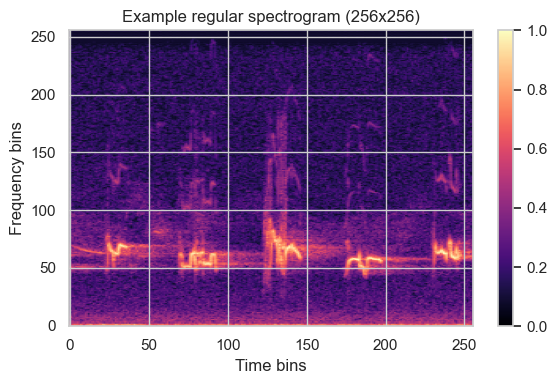

In [9]:
if SPEC_MANIFEST_PARQUET.exists():
    m = pd.read_parquet(SPEC_MANIFEST_PARQUET)
    print("Manifest rows:", len(m))
    print("By split:")
    print(m["split"].value_counts())

    ex = np.load(m.iloc[0]["spectrogram_path"])
    print("Example shape:", ex.shape, "dtype:", ex.dtype, "min/max:", float(ex.min()), float(ex.max()))

    plt.figure(figsize=(6, 4))
    plt.imshow(ex, aspect="auto", origin="lower", cmap="magma")
    plt.title("Example regular spectrogram (256x256)")
    plt.xlabel("Time bins")
    plt.ylabel("Frequency bins")
    plt.colorbar()
    plt.tight_layout()
else:
    print("No spectrogram manifest found yet. Run export cell first.")


## 13) Spectrogram Export Integrity Checks

Run this after export to verify split counts, file presence, shape/dtype/range, and zip consistency.


In [10]:
import zipfile

SPEC_MANIFEST = ARTIFACTS / "spectrograms_256x256_manifest.parquet"
SPEC_TRAIN_CSV = ARTIFACTS / "train_spec256.csv"
SPEC_VAL_CSV = ARTIFACTS / "val_spec256.csv"
SPEC_TEST_CSV = ARTIFACTS / "test_spec256.csv"
SPEC_ZIP = ARTIFACTS / "spectrograms_256x256.zip"

required = [SPEC_MANIFEST, SPEC_TRAIN_CSV, SPEC_VAL_CSV, SPEC_TEST_CSV, SPEC_ZIP]
missing = [str(x) for x in required if not x.exists()]
if missing:
    raise FileNotFoundError(f"Missing spectrogram artifacts: {missing}")

m = pd.read_parquet(SPEC_MANIFEST)
tr = pd.read_csv(SPEC_TRAIN_CSV)
va = pd.read_csv(SPEC_VAL_CSV)
te = pd.read_csv(SPEC_TEST_CSV)

base_tr = pd.read_csv(ARTIFACTS / "train.csv")
base_va = pd.read_csv(ARTIFACTS / "val.csv")
base_te = pd.read_csv(ARTIFACTS / "test.csv")

# 1) Split count checks
assert len(tr) == len(base_tr), f"train count mismatch: spec={len(tr)} base={len(base_tr)}"
assert len(va) == len(base_va), f"val count mismatch: spec={len(va)} base={len(base_va)}"
assert len(te) == len(base_te), f"test count mismatch: spec={len(te)} base={len(base_te)}"
assert len(m) == len(tr) + len(va) + len(te), "Manifest row count != sum(split CSV rows)"

# 2) Manifest schema checks
for c in ["split", "species_label", "spectrogram_path"]:
    assert c in m.columns, f"Missing required column: {c}"
assert m["species_label"].isna().sum() == 0, "species_label has NaNs"
assert m["split"].isna().sum() == 0, "split has NaNs"
assert m["spectrogram_path"].nunique() == len(m), "spectrogram_path not unique"

# 3) File existence checks
exists_mask = m["spectrogram_path"].map(lambda x: Path(x).exists())
missing_n = int((~exists_mask).sum())
assert missing_n == 0, f"Missing spectrogram files: {missing_n}"

# 4) Sample content checks (shape / dtype / range)
sample_n = min(30, len(m))
sample_idx = np.linspace(0, len(m) - 1, num=sample_n, dtype=int)
for i in sample_idx:
    arr = np.load(m.iloc[int(i)]["spectrogram_path"])
    assert tuple(arr.shape) == (256, 256), f"Bad shape: {arr.shape}"
    assert str(arr.dtype) == "float16", f"Bad dtype: {arr.dtype}"
    mn, mx = float(arr.min()), float(arr.max())
    assert mn >= -1e-5 and mx <= 1 + 1e-5, f"Out-of-range values: min={mn}, max={mx}"

# 5) Zip content checks
with zipfile.ZipFile(SPEC_ZIP, "r") as zf:
    names = zf.namelist()
npy_count = sum(1 for n in names if n.lower().endswith(".npy"))
assert npy_count == len(m), f"Zip npy count mismatch: zip={npy_count}, manifest={len(m)}"

report = pd.DataFrame([
    {"check": "manifest_rows", "value": int(len(m))},
    {"check": "train_rows", "value": int(len(tr))},
    {"check": "val_rows", "value": int(len(va))},
    {"check": "test_rows", "value": int(len(te))},
    {"check": "missing_spectrogram_files", "value": missing_n},
    {"check": "zip_npy_count", "value": int(npy_count)},
    {"check": "sample_content_checks", "value": int(sample_n)},
])
display(report)
print("All spectrogram integrity checks passed.")


,check,value
0,manifest_rows,5348
1,train_rows,3742
2,val_rows,815
3,test_rows,791
4,missing_spectrogram_files,0
5,zip_npy_count,5348
6,sample_content_checks,30


All spectrogram integrity checks passed.
